<a href="https://colab.research.google.com/github/UFPAJoaoVictorIA/Atividade-0---IA--Claudomiro/blob/main/Atividade_0_MAGIC__GAMMA_App_Parte_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

# MAGIC Gamma App
### Classificação de eventos astronômicos com Inteligência Artificial

**Atividade 0 - Apresentação em Jupyter / Google Colab**  
Nome: **João Victor** | Disciplina: **Inteligencia Artificial** | Data: **21/09/2026** Docente: **Claudomiro Sales**

---

> **Ideia do aplicativo:** apoiar a identificação de chuveiros atmosféricos produzidos por raios gama, separando-os do ruído de hádrons a partir das medições de um telescópio Cherenkov.

</div>

## Índice

1. [Tema e problema](#tema-e-problema)
2. [Proposta do aplicativo](#proposta-do-aplicativo)
3. [Dataset MAGIC](#dataset-magic)
4. [Carregamento e tratamento dos dados](#carregamento-e-tratamento-dos-dados)
5. [Análise exploratória](#análise-exploratória)
6. [Modelo de IA](#modelo-de-ia)
7. [Aplicativo interativo](#aplicativo-interativo)
8. [Conclusão, limites e referências](#conclusão-limites-e-referências)

---

**Como usar:** execute as células na ordem. No Google Colab, abra este arquivo e use **Ambiente de execução > Executar tudo**.

## Tema e problema

### Detecção de raios gama em astronomia

Telescópios Cherenkov observam flashes de luz gerados quando partículas de alta energia atingem a atmosfera. O desafio é distinguir:

| Classe | Significado | Decisão desejada |
|---|---|---|
| g | evento associado a **raio gama** | preservar para análise científica |
| h | evento associado a **hádrons** (fundo/ruído) | filtrar ou revisar |

Uma classificação rápida e consistente pode reduzir o volume de eventos que precisa de análise manual e apoiar estudos de fontes cósmicas de alta energia.

## Proposta do aplicativo

### MAGIC Gamma App: apoio à triagem de eventos

~~~text
Medições do telescópio
          ↓
Tratamento e padronização
          ↓
Modelo de IA treinado
          ↓
Probabilidade de ser raio gama
          ↓
Triagem: “candidato a gama” ou “provável hádron”
~~~

**Usuários possíveis:** estudantes, pesquisadores e equipes de observação.  
**Entrega desta demonstração:** uma tela interativa onde a pessoa informa as 10 medições de um evento e recebe a previsão do modelo.

## Dataset MAGIC

O conjunto **MAGIC Gamma Telescope** foi disponibilizado pelo repositório UCI Machine Learning. Ele contém **19.020 eventos** e **10 atributos numéricos**, além da classe (g ou h).

| Grupo | Atributos |
|---|---|
| Forma da elipse | fLength, fWidth, fSize |
| Intensidade e distribuição | fConc, fConc1, fAsym |
| Posição/orientação | fM3Long, fM3Trans, fAlpha, fDist |

**Fonte dos dados:** [UCI - MAGIC Gamma Telescope](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope).  
O código abaixo utiliza o mesmo arquivo de dados apresentado no material da aula.

## Carregamento e tratamento dos dados

Nesta etapa repetimos o fluxo essencial mostrado em aula: importar bibliotecas, carregar o arquivo a partir da URL, nomear as colunas, inspecionar a tabela e verificar sua qualidade.

In [ ]:
# Bibliotecas usadas na análise e no modelo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

In [ ]:
# Arquivo original do repositório UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"

colunas = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "classe"
]

df = pd.read_csv(url, header=None, names=colunas)
print(f"Dimensão do dataset: {df.shape[0]:,} linhas e {df.shape[1]:,} colunas")
df.head()

Dimensão do dataset: 19,020 linhas e 11 colunas


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,classe
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
# Inspeção inicial: tipos de dados, valores ausentes e duplicados
display(df.info())
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes").T)
print(f"\nLinhas duplicadas: {df.duplicated().sum():,}")
print("\nResumo estatístico:")
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  classe    19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


None


Valores ausentes por coluna:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,classe
ausentes,0,0,0,0,0,0,0,0,0,0,0



Linhas duplicadas: 115

Resumo estatístico:


,count,mean,std,min,25%,50%,75%,max
fLength,19020.0,53.250154,42.364855,4.2835,24.336000,37.14770,70.122175,334.1770
fWidth,19020.0,22.180966,18.346056,0.0000,11.863800,17.13990,24.739475,256.3820
fSize,19020.0,2.825017,0.472599,1.9413,2.477100,2.73960,3.101600,5.3233
fConc,19020.0,0.380327,0.182813,0.0131,0.235800,0.35415,0.503700,0.8930
fConc1,19020.0,0.214657,0.110511,0.0003,0.128475,0.19650,0.285225,0.6752
fAsym,19020.0,-4.331745,59.206062,-457.9161,-20.586550,4.01305,24.063700,575.2407
fM3Long,19020.0,10.545545,51.000118,-331.7800,-12.842775,15.31410,35.837800,238.3210
fM3Trans,19020.0,0.249726,20.827439,-205.8947,-10.849375,0.66620,10.946425,179.8510
fAlpha,19020.0,27.645707,26.103621,0.0000,5.547925,17.67950,45.883550,90.0000
fDist,19020.0,193.818026,74.731787,1.2826,142.492250,191.85145,240.563825,495.5610


In [ ]:
# Tratamento: remover duplicatas (se existirem) e criar o alvo binário
df = df.drop_duplicates().copy()
df["alvo"] = (df["classe"] == "g").astype(int)  # 1 = raio gama; 0 = hádron

rotulos = df["classe"].map({"g": "Raio gama (g)", "h": "Hádrons (h)"})
print("Classes após o tratamento:")
display(rotulos.value_counts().rename_axis("classe").to_frame("quantidade"))
print("\nNão há imputação: a checagem acima confirma que o dataset não possui valores ausentes.")

Classes após o tratamento:


,quantidade
classe,
Raio gama (g),12332
Hádrons (h),6573



Não há imputação: a checagem acima confirma que o dataset não possui valores ausentes.


## Análise exploratória

Os gráficos abaixo ajudam a compreender o equilíbrio das classes e se algumas medidas apresentam padrões diferentes entre eventos gama e hádrons.

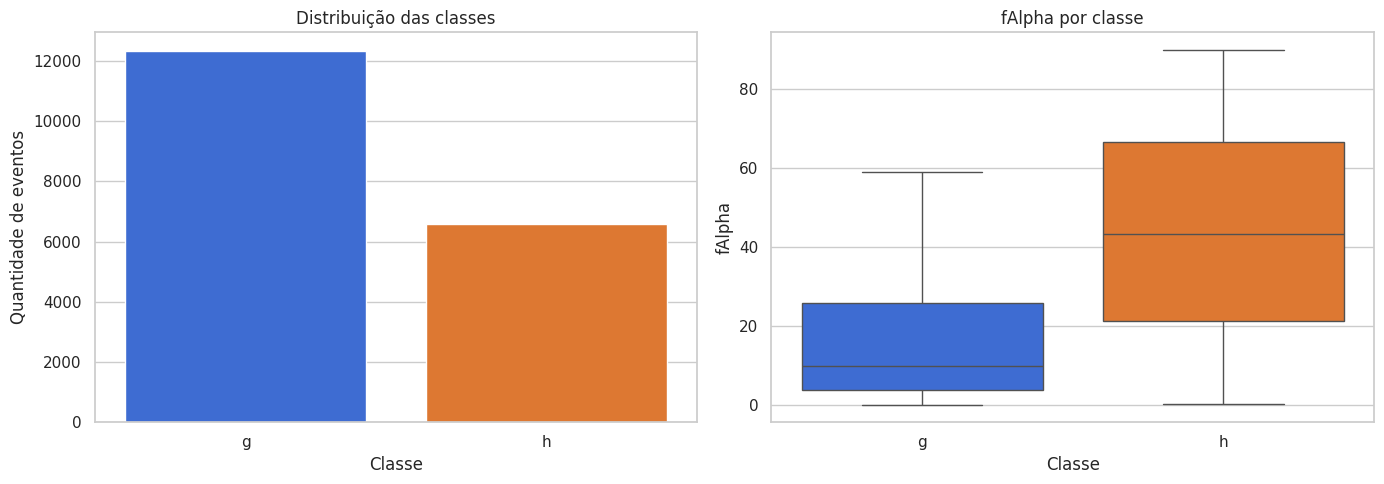

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="classe", hue="classe", legend=False, ax=axes[0],
              palette={"g": "#2563eb", "h": "#f97316"})
axes[0].set_title("Distribuição das classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade de eventos")

sns.boxplot(data=df, x="classe", y="fAlpha", hue="classe", legend=False, ax=axes[1],
            palette={"g": "#2563eb", "h": "#f97316"}, showfliers=False)
axes[1].set_title("fAlpha por classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("fAlpha")

plt.tight_layout()
plt.show()

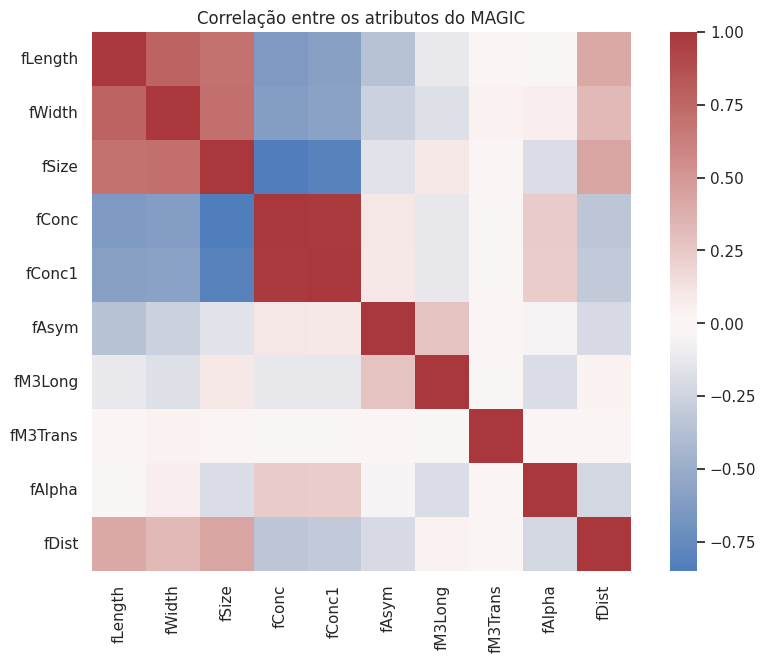

Leitura rápida: o modelo deve aprender combinações entre atributos; uma única medida não descreve completamente um evento.


In [ ]:
# Correlação entre as medições numéricas
plt.figure(figsize=(10, 7))
sns.heatmap(df[colunas[:-1]].corr(), cmap="vlag", center=0, square=True)
plt.title("Correlação entre os atributos do MAGIC")
plt.show()

print("Leitura rápida: o modelo deve aprender combinações entre atributos; uma única medida não descreve completamente um evento.")

## Modelo de IA

### Estratégia

- **Entrada:** as 10 medições numéricas do telescópio.
- **Saída:** probabilidade de o evento pertencer à classe g.
- **Divisão:** 80% para treinamento e 20% para teste, preservando a proporção das classes.
- **Modelo:** *Random Forest*, escolhido por funcionar bem com relações não lineares e oferecer uma base sólida para a demonstração.

> A previsão é uma ferramenta de apoio; ela não substitui validação científica nem decisão humana.

In [ ]:
atributos = colunas[:-1]
X = df[atributos]
y = df["alvo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# O StandardScaler deixa o pipeline pronto para comparação/expansão com outros modelos.
# A floresta é treinada com uma semente fixa para tornar a apresentação reproduzível.
modelo = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("classificador", RandomForestClassifier(
        n_estimators=250, min_samples_leaf=2, random_state=42, n_jobs=-1,
        class_weight="balanced"
    ))
])

modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)
prob_gama = modelo.predict_proba(X_test)[:, 1]

print(f"ROC-AUC no conjunto de teste: {roc_auc_score(y_test, prob_gama):.3f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, pred, target_names=["Hádrons", "Raio gama"]))

ROC-AUC no conjunto de teste: 0.934

Relatório de classificação:
              precision    recall  f1-score   support

     Hádrons       0.86      0.77      0.81      1315
   Raio gama       0.89      0.93      0.91      2466

    accuracy                           0.88      3781
   macro avg       0.87      0.85      0.86      3781
weighted avg       0.88      0.88      0.88      3781



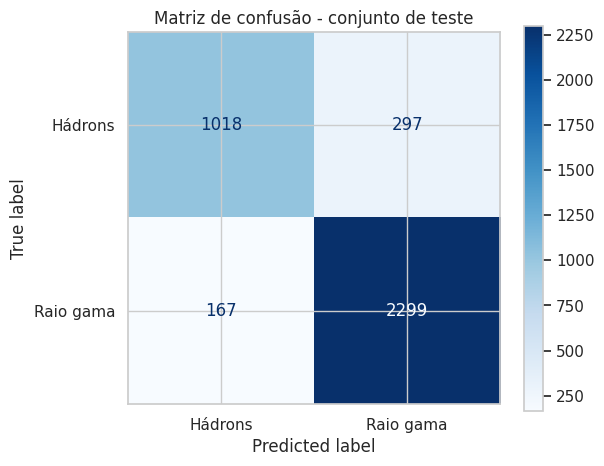

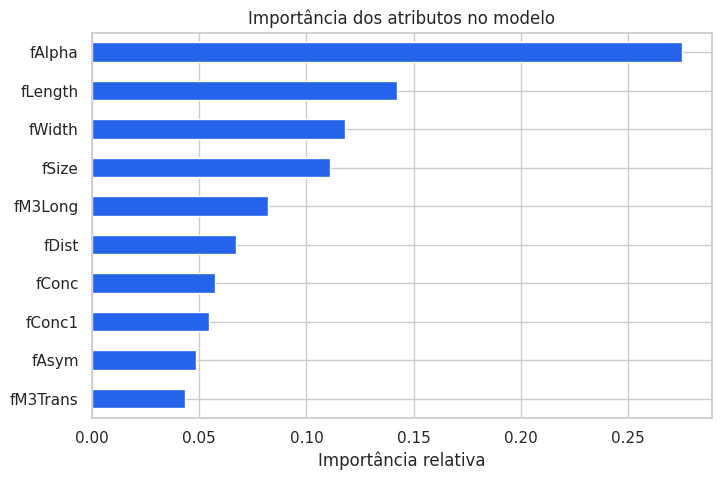

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["Hádrons", "Raio gama"], cmap="Blues", ax=ax
)
ax.set_title("Matriz de confusão - conjunto de teste")
plt.show()

importancias = pd.Series(
    modelo.named_steps["classificador"].feature_importances_, index=atributos
).sort_values()

plt.figure(figsize=(8, 5))
importancias.plot.barh(color="#2563eb")
plt.title("Importância dos atributos no modelo")
plt.xlabel("Importância relativa")
plt.show()

## Aplicativo interativo

Execute a célula abaixo após treinar o modelo. Ajuste as medições de um evento e clique em **Classificar evento**.

<small>Os valores iniciais são a mediana do conjunto de dados, apenas para facilitar a experimentação.</small>

In [ ]:
# Interface simples para Google Colab/Jupyter
import ipywidgets as widgets
from IPython.display import display, clear_output

medianas = X.median()
controles = {}
for atributo in atributos:
    controles[atributo] = widgets.FloatText(
        value=float(medianas[atributo]), description=atributo,
        layout=widgets.Layout(width="260px")
    )

botao = widgets.Button(description="Classificar evento", button_style="primary", icon="search")
saida = widgets.Output()

def classificar_evento(_):
    entrada = pd.DataFrame([{nome: campo.value for nome, campo in controles.items()}])
    probabilidade = float(modelo.predict_proba(entrada)[0, 1])
    classe = "CANDIDATO A RAIO GAMA" if probabilidade >= 0.5 else "PROVÁVEL HÁDRON"
    cor = "#166534" if probabilidade >= 0.5 else "#9a3412"
    with saida:
        clear_output()
        display(pd.DataFrame({"Medição": entrada.iloc[0]}).T)
        display(widgets.HTML(
            f"<h3 style='color:{cor}; margin:12px 0'>{classe}</h3>"
            f"<p>Probabilidade estimada de raio gama: <b>{probabilidade:.1%}</b></p>"
            "<p><small>Resultado educacional: confirme eventos relevantes com o protocolo científico adequado.</small></p>"
        ))

botao.on_click(classificar_evento)
interface = widgets.VBox([
    widgets.HTML("<h3>MAGIC Gamma App</h3><p>Informe as características do evento:</p>"),
    widgets.GridBox(list(controles.values()),
        layout=widgets.Layout(grid_template_columns="repeat(2, 270px)", grid_gap="8px")),
    botao, saida
])
display(interface)

## Conclusão, limites e referências

### Conclusão

O notebook transforma medições do telescópio em uma estimativa de classe, conectando um problema de astronomia a uma aplicação prática de IA. O fluxo completo inclui carregamento, tratamento, exploração, treinamento, avaliação e uma interface de uso.

### Limites e cuidados

- O dataset é histórico e representa um contexto específico de aquisição.
- A probabilidade não é certeza; erros de classificação são esperados.
- Antes de uso operacional, é necessário validar o modelo em dados recentes, monitorar desempenho e definir revisão humana para casos críticos.



---
**Fim da apresentação.**